# Regression example using PT-MELT
This is a basic regression example using the models in PT-MELT.

Requires the following additional packages:
* ipykernel
* scikit-learn
* matplotlib
* torchinfo

In [1]:
import sklearn.datasets as sdt
import matplotlib.pyplot as plt

# Create surogate data
n_samples = 1000
n_features = 10
n_info = 5
n_targets = 3
noise = 1

x, y = sdt.make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_info,
    n_targets=n_targets,
    noise=noise,
    random_state=42,
)
print(f"Shape of x: {x.shape}, Shape of y: {y.shape}")

Shape of x: (1000, 10), Shape of y: (1000, 3)


In [2]:
# Use sklearn scaling libraries to normalize the data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x_normalizer = StandardScaler()
y_normalizer = StandardScaler()

x_normalizer.fit(x)
y_normalizer.fit(y)

x_norm = x_normalizer.transform(x)
y_norm = y_normalizer.transform(y)

# Create train and test datasets
x_train, x_test, y_train, y_test = train_test_split(
    x_norm, y_norm, test_size=0.2, random_state=42
)
# Create the validation dataset from the test dataset
x_test, x_val, y_test, y_val = train_test_split(
    x_test, y_test, test_size=0.5, random_state=42
)

# Precompute the un-normalized data for later use
y_train_real = y_normalizer.inverse_transform(y_train)
y_test_real = y_normalizer.inverse_transform(y_test)
y_val_real = y_normalizer.inverse_transform(y_val)

# Hyperparameters
Set consistent hyperparameters for all models for comparisons sake.

In [3]:
# General hyperparameters
n_epochs = 300
batch_size = 32
loss = "mse"
learn_rate = 1e-3
l1_reg = 0
l2_reg = 0
act_fun = "relu"
dropout = 0.1
input_dropout = 0.1
batch_norm = False
batch_norm_type = "ema"
output_activation = "linear"

width = 8
depth = 2

# ResNet specific hyperparameters
layers_per_block = 4

# Make a history dict for storing metrics
# history = {"loss": [], "val_loss": []}

## Artificial Neural Network (ANN)
Create and train an ANN using PT-MELT.

In [4]:
from ptmelt.models import ArtificialNeuralNetwork
from torchinfo import summary
import torch
from torch import optim


# Create the model
ann_model = ArtificialNeuralNetwork(
    num_features=n_features,
    num_outputs=n_targets,
    width=width,
    depth=depth,
    act_fun=act_fun,
    l1_reg=l1_reg,
    l2_reg=l2_reg,
    input_dropout=input_dropout,
    dropout=dropout,
    batch_norm=batch_norm,
    batch_norm_type=batch_norm_type,
    output_activation=output_activation,
)


# Build the model and print the summary
ann_model.build()
print(summary(ann_model, input_size=(1, n_features)))

# Define the loss function and optimizer for training
criterion = ann_model.get_loss_fn(loss="mse", reduction="mean")
# optimizer = optim.Adam(ann_model.parameters(), lr=learn_rate)
optimizer = ann_model.get_optimizer("Adam", lr=1e-3)
scheduler = ann_model.get_scheduler(
    "ReduceLROnPlateau",
    optimizer,
    factor=0.5,
    patience=50,
    min_lr=1e-6,
    mode="min",
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=10,
)

print(f"Optimizer: {optimizer}")
print(f"Scheduler: {scheduler}")

Layer (type:depth-idx)                   Output Shape              Param #
ArtificialNeuralNetwork                  [1, 3]                    --
├─ModuleDict: 1-1                        --                        --
│    └─Dropout: 2-1                      [1, 10]                   --
│    └─DenseBlock: 2-2                   [1, 8]                    --
│    │    └─ModuleDict: 3-1              --                        160
│    └─DefaultOutput: 2-3                [1, 3]                    --
│    │    └─Linear: 3-2                  [1, 3]                    27
│    │    └─Identity: 3-3                [1, 3]                    --
Total params: 187
Trainable params: 187
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
   

In [5]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Create the data holder for training/validation (the test set should be held separate from any model training)
dataset = TensorDataset(
    torch.from_numpy(x_train).float(), torch.from_numpy(y_train).float()
)
dataset_val = TensorDataset(
    torch.from_numpy(x_val).float(), torch.from_numpy(y_val).float()
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=True)

In [6]:
# Fit the model using the built-in training loop
ann_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    stopping=True,  # Use early stopping
    num_epochs=1000,
    verbose=True,
)

history = ann_model.history

  1%|          | 11/1000 [00:00<00:09, 107.37it/s]

Epoch 10, Loss: 0.8552, Val Loss: 1.2286
Epoch 20, Loss: 0.3469, Val Loss: 0.1692


  2%|▏         | 24/1000 [00:00<00:08, 117.99it/s]

Epoch 30, Loss: 0.2773, Val Loss: 0.1153


  5%|▌         | 50/1000 [00:00<00:07, 124.23it/s]

...

Epoch 700, Loss: 0.1593, Val Loss: 0.0698
Epoch 710, Loss: 0.1850, Val Loss: 0.0650


 72%|███████▏  | 717/1000 [00:05<00:02, 124.88it/s]

Epoch 720, Loss: 0.1642, Val Loss: 0.0734


 74%|███████▎  | 735/1000 [00:05<00:02, 126.49it/s]

Epoch 730, Loss: 0.1491, Val Loss: 0.0648
Stopping training at epoch 736 due to learning rate reaching minimum 1e-06.


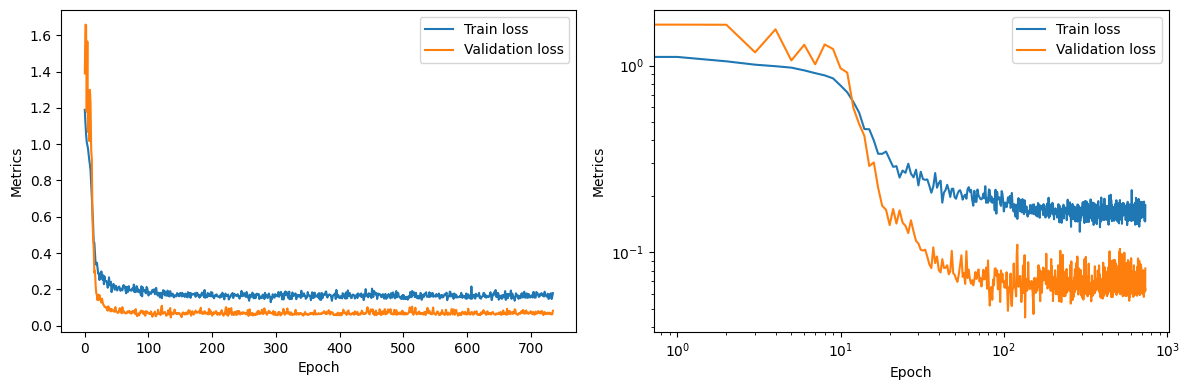

In [7]:
from ptmelt.utils.visualization import plot_history

# Plot the training history
plot_history(history, metrics=["loss"], plot_log=True)

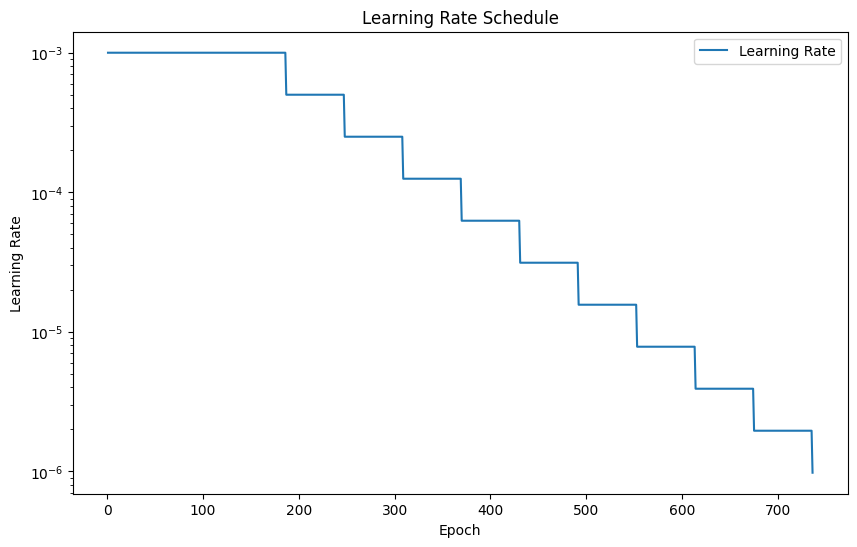

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(history["epoch"], history["lr"], label="Learning Rate")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.legend()

In [9]:
from ptmelt.utils.evaluation import make_predictions

# Evaluate the model performance on train, validation, and test data
pred_train = make_predictions(
    ann_model, x_train, y_normalizer=y_normalizer, unnormalize=True
)
pred_val = make_predictions(
    ann_model, x_val, y_normalizer=y_normalizer, unnormalize=True
)
pred_test = make_predictions(
    ann_model, x_test, y_normalizer=y_normalizer, unnormalize=True
)

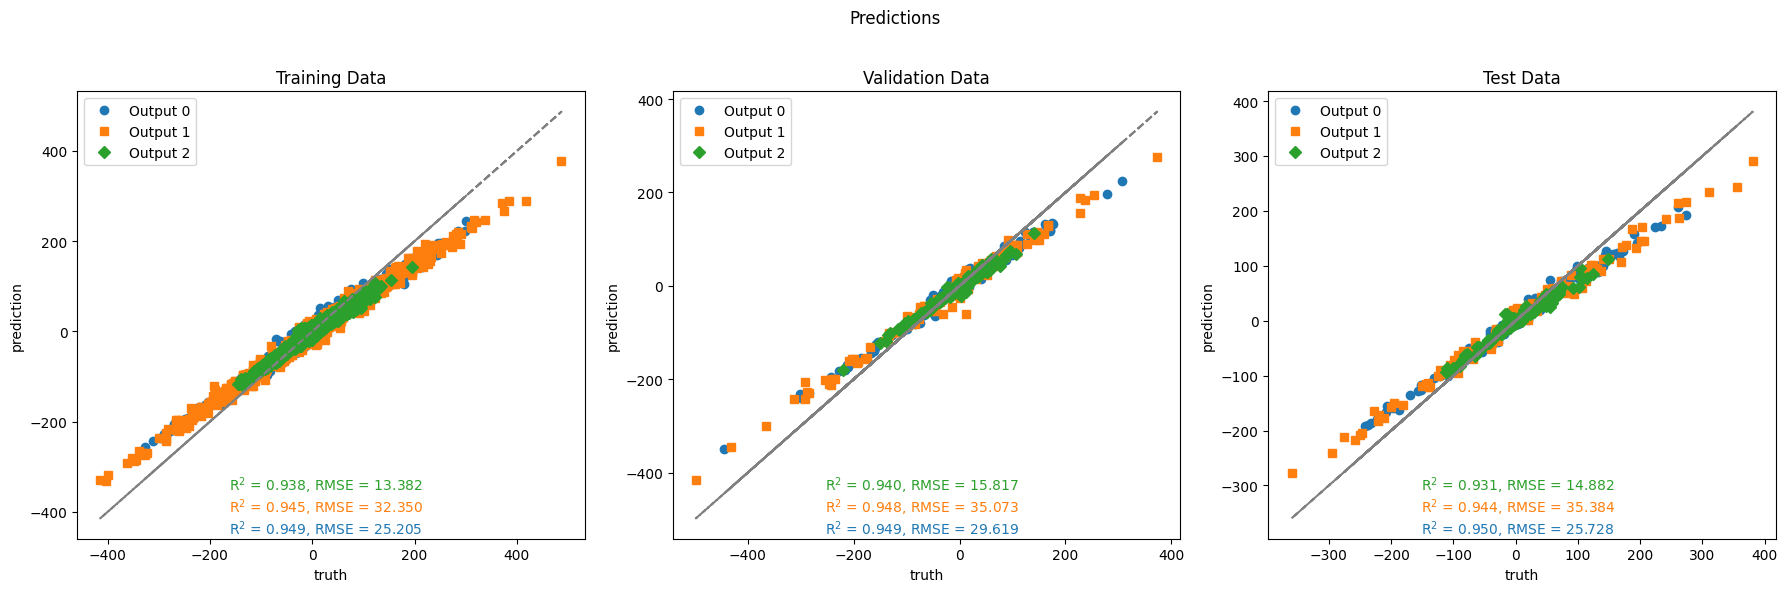

In [10]:
from ptmelt.utils.visualization import plot_predictions

# Plot the predictions
plot_predictions(pred_train, y_train_real, pred_val, y_val_real, pred_test, y_test_real)

In [11]:
from ptmelt.utils.evaluation import ensemble_predictions

# Make ensemble predictions using MC Dropout
n_iter = 100
pred_train_mean, pred_train_std = ensemble_predictions(
    ann_model,
    x_train,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_val_mean, pred_val_std = ensemble_predictions(
    ann_model,
    x_val,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_test_mean, pred_test_std = ensemble_predictions(
    ann_model,
    x_test,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)

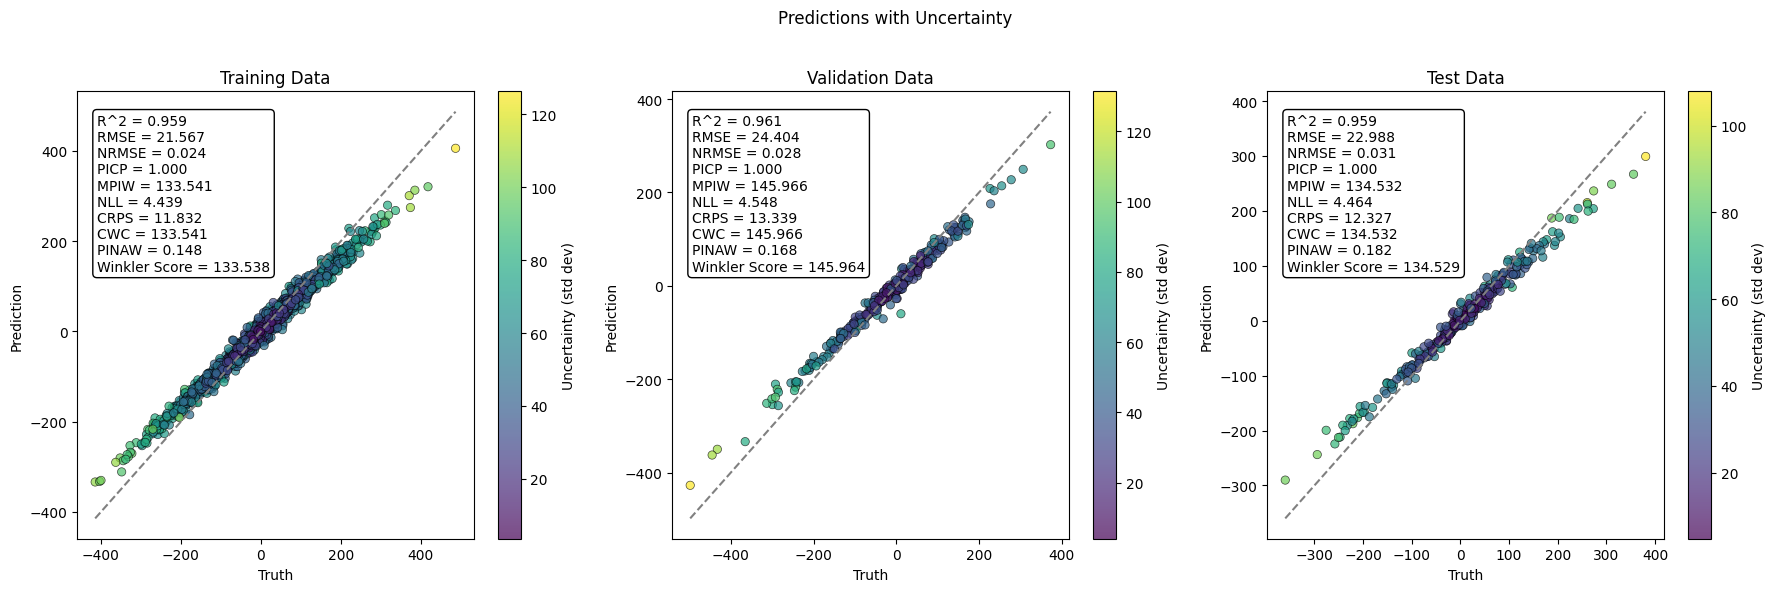

In [12]:
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Plot MC Dropout predictions
plot_predictions_with_uncertainty(
    pred_train_mean,
    pred_train_std,
    y_train_real,
    pred_val_mean,
    pred_val_std,
    y_val_real,
    pred_test_mean,
    pred_test_std,
    y_test_real,
    metrics_to_display=None,  # Display all metrics
)

## Residual Neural Network (ResNet)
Create and train a ResNet using PT-MELT.

In [13]:
from ptmelt.models import ResidualNeuralNetwork

# Create the model
resnet_model = ResidualNeuralNetwork(
    num_features=n_features,
    num_outputs=n_targets,
    width=width,
    depth=depth,
    layers_per_block=layers_per_block,
    act_fun=act_fun,
    l1_reg=l1_reg,
    l2_reg=l2_reg,
    input_dropout=input_dropout,
    dropout=dropout,
    batch_norm=batch_norm,
    batch_norm_type=batch_norm_type,
    pre_activation=True,
    post_add_activation=False,
    output_activation=output_activation,
)

# Build the model and print the summary
resnet_model.build()
print(summary(resnet_model, input_size=(1, n_features)))

# Define the loss function and optimizer for training
criterion = resnet_model.get_loss_fn(loss="mse", reduction="mean")
optimizer = resnet_model.get_optimizer("Adam", lr=learn_rate)
scheduler = resnet_model.get_scheduler(
    "ReduceLROnPlateau",
    optimizer,
    factor=0.5,
    patience=50,
    min_lr=1e-6,
    mode="min",
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=10,
)

print(f"Optimizer: {optimizer}")
print(f"Scheduler: {scheduler}")

Layer (type:depth-idx)                   Output Shape              Param #
ResidualNeuralNetwork                    [1, 3]                    --
├─ModuleDict: 1-1                        --                        --
│    └─Dropout: 2-1                      [1, 10]                   --
│    └─ResidualBlock: 2-2                [1, 8]                    --
│    │    └─ModuleDict: 3-1              --                        160
│    └─DefaultOutput: 2-3                [1, 3]                    --
│    │    └─Linear: 3-2                  [1, 3]                    27
│    │    └─Identity: 3-3                [1, 3]                    --
Total params: 187
Trainable params: 187
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
   

/Users/nwimer/NREL_Repos/pt-melt/ptmelt/models.py:476: UserWarning: Warning: depth 2 is not divisible by layers_per_block (4), so the last block will have 2 layers.
  warnings.warn(
/Users/nwimer/NREL_Repos/pt-melt/ptmelt/blocks.py:239: UserWarning: Warning: Number of layers 2 is not divisible by layers_per_block (4), so the last block will have 2 layers.
  warnings.warn(


In [14]:
# Fit the model using the built-in training loop
n_epochs = 1000
resnet_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    stopping=True,
    num_epochs=n_epochs,
    verbose=True,
)

history = resnet_model.history

  1%|          | 12/1000 [00:00<00:08, 113.30it/s]

Epoch 10, Loss: 0.6457, Val Loss: 0.6114
Epoch 20, Loss: 0.3221, Val Loss: 0.2397


  2%|▎         | 25/1000 [00:00<00:08, 119.76it/s]

Epoch 30, Loss: 0.2448, Val Loss: 0.1164


  5%|▌         | 51/1000 [00:00<00:07, 124.00it/s]

...

Epoch 750, Loss: 0.1300, Val Loss: 0.0528


 77%|███████▋  | 767/1000 [00:06<00:01, 128.47it/s]

Epoch 760, Loss: 0.1421, Val Loss: 0.0465
Epoch 770, Loss: 0.1271, Val Loss: 0.0479


 78%|███████▊  | 780/1000 [00:06<00:01, 126.16it/s]

Epoch 780, Loss: 0.1207, Val Loss: 0.0416
Stopping training at epoch 781 due to learning rate reaching minimum 1e-06.


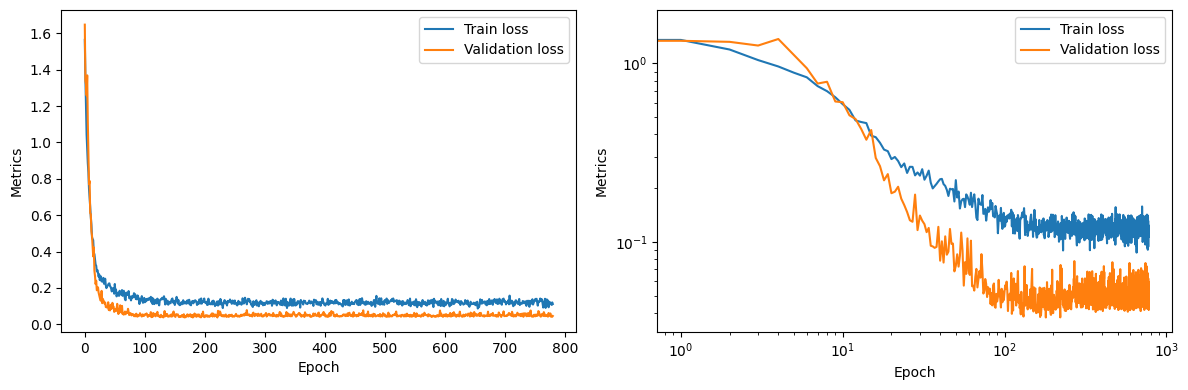

In [15]:
from ptmelt.utils.visualization import plot_history

# Plot the training history
plot_history(history, metrics=["loss"], plot_log=True)

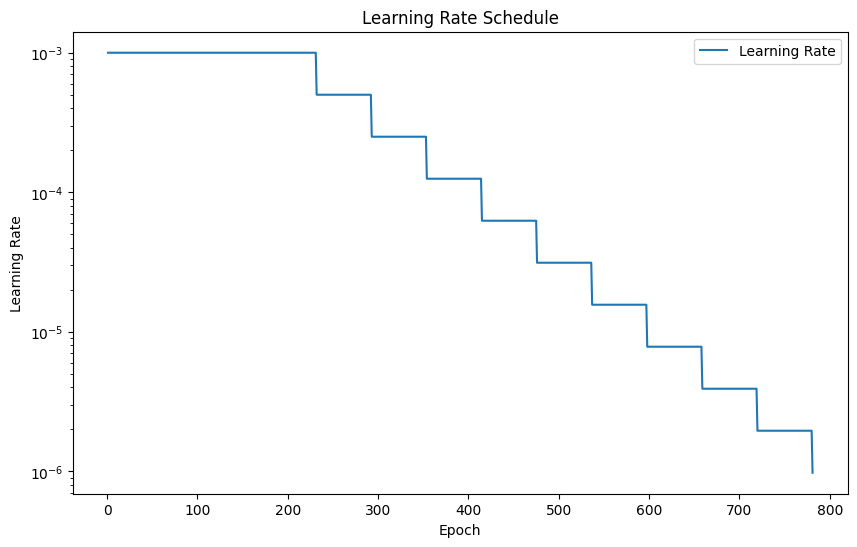

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(history["epoch"], history["lr"], label="Learning Rate")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.legend()

In [17]:
from ptmelt.utils.evaluation import make_predictions

# Evaluate the model performance on train, validation, and test data
pred_train = make_predictions(
    resnet_model, x_train, y_normalizer=y_normalizer, unnormalize=True
)
pred_val = make_predictions(
    resnet_model, x_val, y_normalizer=y_normalizer, unnormalize=True
)
pred_test = make_predictions(
    resnet_model, x_test, y_normalizer=y_normalizer, unnormalize=True
)

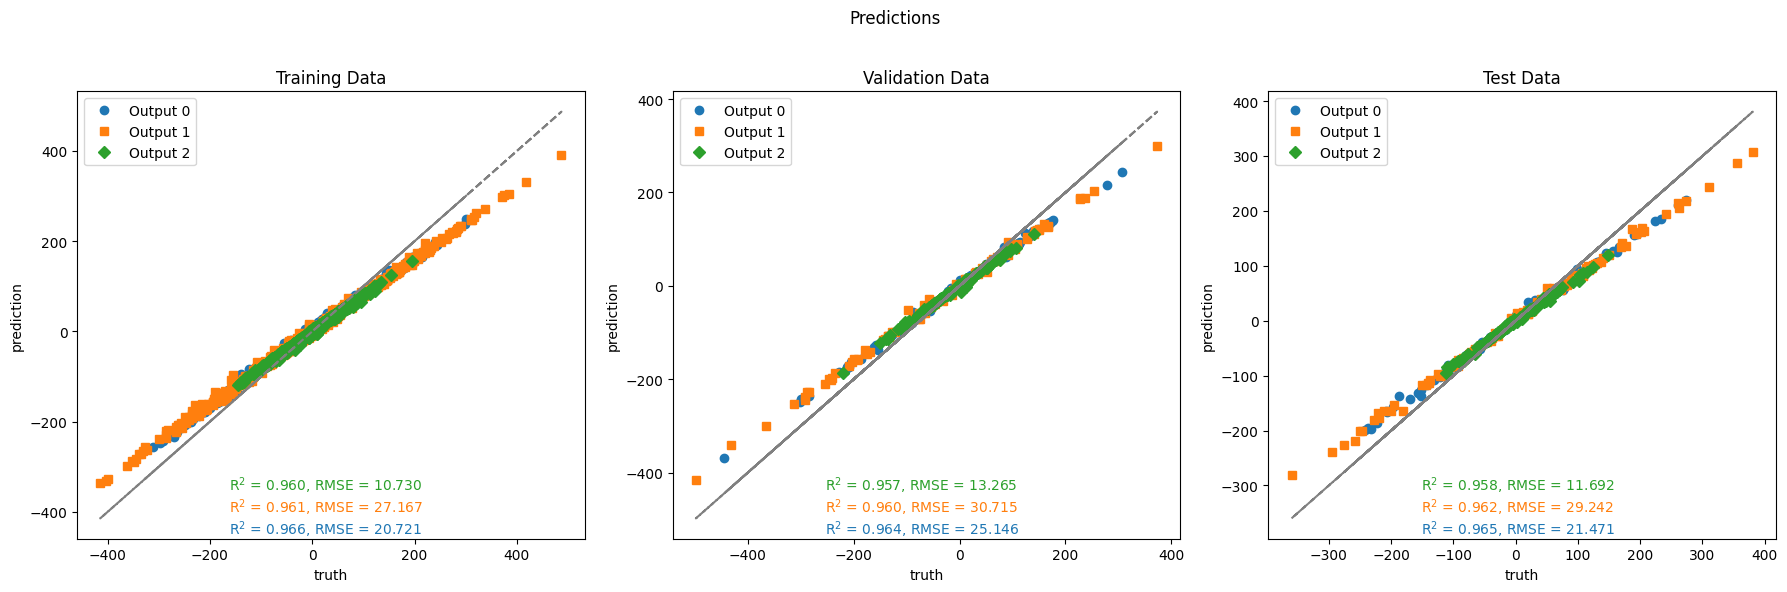

In [18]:
from ptmelt.utils.visualization import plot_predictions

# Plot the predictions
plot_predictions(pred_train, y_train_real, pred_val, y_val_real, pred_test, y_test_real)

In [19]:
from ptmelt.utils.evaluation import ensemble_predictions

# Make ensemble predictions using MC Dropout
n_iter = 100
pred_train_mean, pred_train_std = ensemble_predictions(
    resnet_model,
    x_train,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_val_mean, pred_val_std = ensemble_predictions(
    resnet_model,
    x_val,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_test_mean, pred_test_std = ensemble_predictions(
    resnet_model,
    x_test,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)

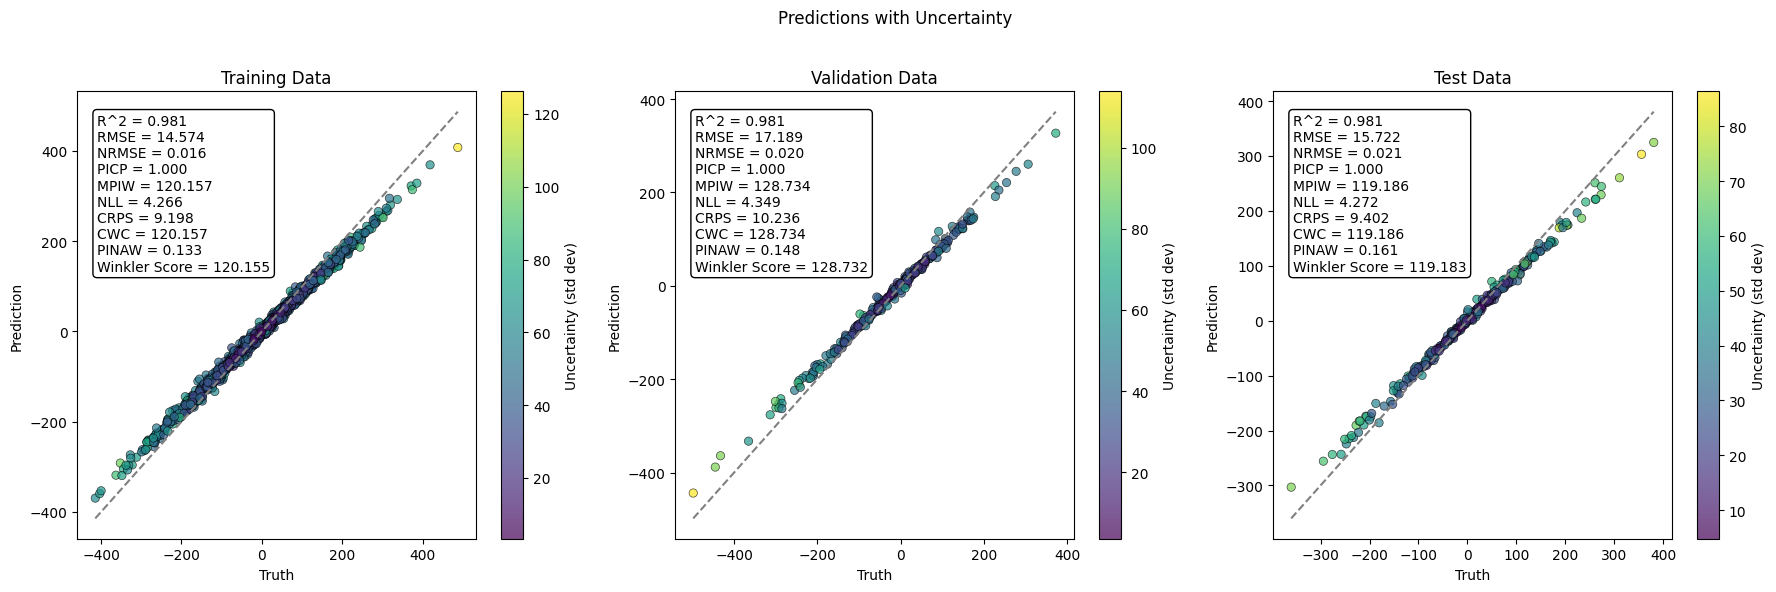

In [20]:
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Plot MC Dropout predictions
plot_predictions_with_uncertainty(
    pred_train_mean,
    pred_train_std,
    y_train_real,
    pred_val_mean,
    pred_val_std,
    y_val_real,
    pred_test_mean,
    pred_test_std,
    y_test_real,
    metrics_to_display=None,  # Display all metrics
)

# Mixture Density Network

Test the MDN with varying numbers of mixtures (when mixtures=1, it is a heteroscedastic NN)

In [21]:
from ptmelt.models import ArtificialNeuralNetwork
from torchinfo import summary
from torch import nn, optim

# Create the model
mdn_model = ArtificialNeuralNetwork(
    num_features=n_features,
    num_outputs=n_targets,
    width=width,
    depth=depth,
    act_fun=act_fun,
    l1_reg=l1_reg,
    l2_reg=l2_reg,
    input_dropout=0.0,  # Remove input dropout
    dropout=0.0,  # Remove dropout
    batch_norm=batch_norm,
    batch_norm_type=batch_norm_type,
    output_activation=output_activation,
    num_mixtures=1,
)

# Build the model and print the summary
mdn_model.build()
print(summary(mdn_model, input_size=(1, n_features)))

# Define the loss function and optimizer for training
criterion = mdn_model.get_loss_fn(mse_weight=1.0)
optimizer = mdn_model.get_optimizer("Adam", lr=learn_rate)
scheduler = mdn_model.get_scheduler(
    "ReduceLROnPlateau",
    optimizer,
    factor=0.5,
    patience=50,
    min_lr=1e-6,
    mode="min",
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=10,
)

print(f"Optimizer: {optimizer}")
print(f"Scheduler: {scheduler}")

Layer (type:depth-idx)                   Output Shape              Param #
ArtificialNeuralNetwork                  [1, 7]                    --
├─ModuleDict: 1-1                        --                        --
│    └─DenseBlock: 2-1                   [1, 8]                    --
│    │    └─ModuleDict: 3-1              --                        160
│    └─MixtureDensityOutput: 2-2         [1, 7]                    --
│    │    └─Linear: 3-2                  [1, 1]                    9
│    │    └─Softmax: 3-3                 [1, 1]                    --
│    │    └─Linear: 3-4                  [1, 3]                    27
│    │    └─Linear: 3-5                  [1, 3]                    27
Total params: 223
Trainable params: 223
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.99

/Users/nwimer/miniconda3/envs/pt-melt/lib/python3.12/site-packages/torch/nn/modules/module.py:1532: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/Users/nwimer/NREL_Repos/pt-melt/ptmelt/models.py:210: UserWarning: Mixture Density Networks require the use of the MixtureDensityLoss class. The loss function will be set to automatically.
  warnings.warn(


In [22]:
# Fit the model using the built-in training loop
n_epochs = 1000

mdn_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    stopping=True,
    num_epochs=n_epochs,
    verbose=True,
)

history = mdn_model.history

  2%|▏         | 15/1000 [00:00<00:21, 46.55it/s]

Epoch 10, Loss: 10.5011, Val Loss: 11.6601


  2%|▎         | 25/1000 [00:00<00:20, 46.65it/s]

Epoch 20, Loss: 8.4383, Val Loss: 8.3992


  4%|▎         | 35/1000 [00:00<00:20, 47.26it/s]

...

Epoch 970, Loss: -3.3954, Val Loss: -3.0399
Epoch 980, Loss: -3.3978, Val Loss: -2.3236


100%|█████████▉| 995/1000 [00:21<00:00, 49.14it/s]

Epoch 990, Loss: -3.4003, Val Loss: -2.7826


100%|██████████| 1000/1000 [00:21<00:00, 47.08it/s]

Epoch 1000, Loss: -3.3969, Val Loss: -2.5040


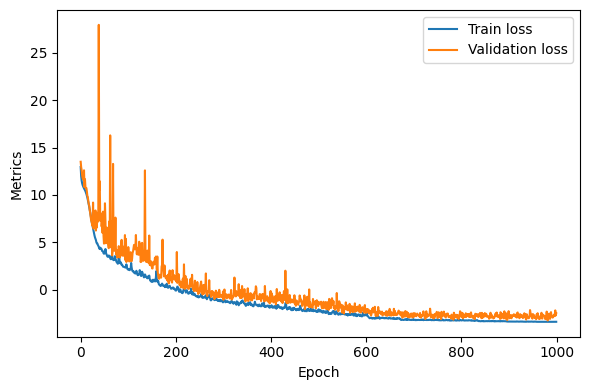

In [23]:
from ptmelt.utils.visualization import plot_history

# Plot the training history
plot_history(history, metrics=["loss"], plot_log=False)

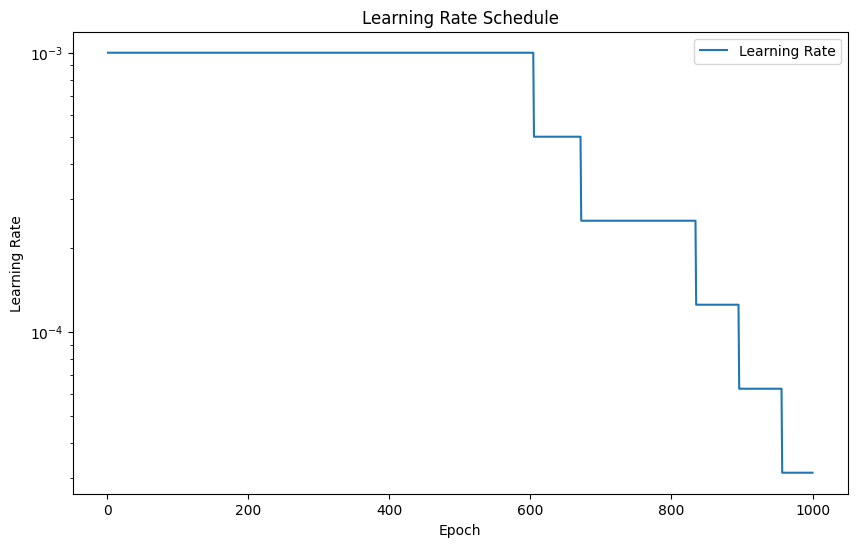

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(history["epoch"], history["lr"], label="Learning Rate")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.legend()

In [25]:
from ptmelt.utils.evaluation import make_predictions

# Evaluate the model performance on train, validation, and test data
pred_train, pred_train_std = make_predictions(
    mdn_model, x_train, y_normalizer=y_normalizer, unnormalize=True
)
pred_val, pred_val_std = make_predictions(
    mdn_model, x_val, y_normalizer=y_normalizer, unnormalize=True
)
pred_test, pred_test_std = make_predictions(
    mdn_model, x_test, y_normalizer=y_normalizer, unnormalize=True
)

/Users/nwimer/miniconda3/envs/pt-melt/lib/python3.12/site-packages/torch/nn/modules/module.py:1532: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/Users/nwimer/miniconda3/envs/pt-melt/lib/python3.12/site-packages/torch/nn/modules/module.py:1532: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/Users/nwimer/miniconda3/envs/pt-melt/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2029: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/Users/nwimer/NREL_Repos/pt-melt/ptmelt/utils/statistics.py:192: RuntimeWarning: divide by zero encountered in divide
  z = (y - mu) / sigma
/Users/nwimer/NREL_Repos/pt-melt/ptmelt/utils/statistics.py:195: RuntimeWarning: invalid value encountered in multiply
  return sigma * (z * (2 * cdf_z - 1) + 2 * pdf_z - 1 / np.sqrt(np.pi))


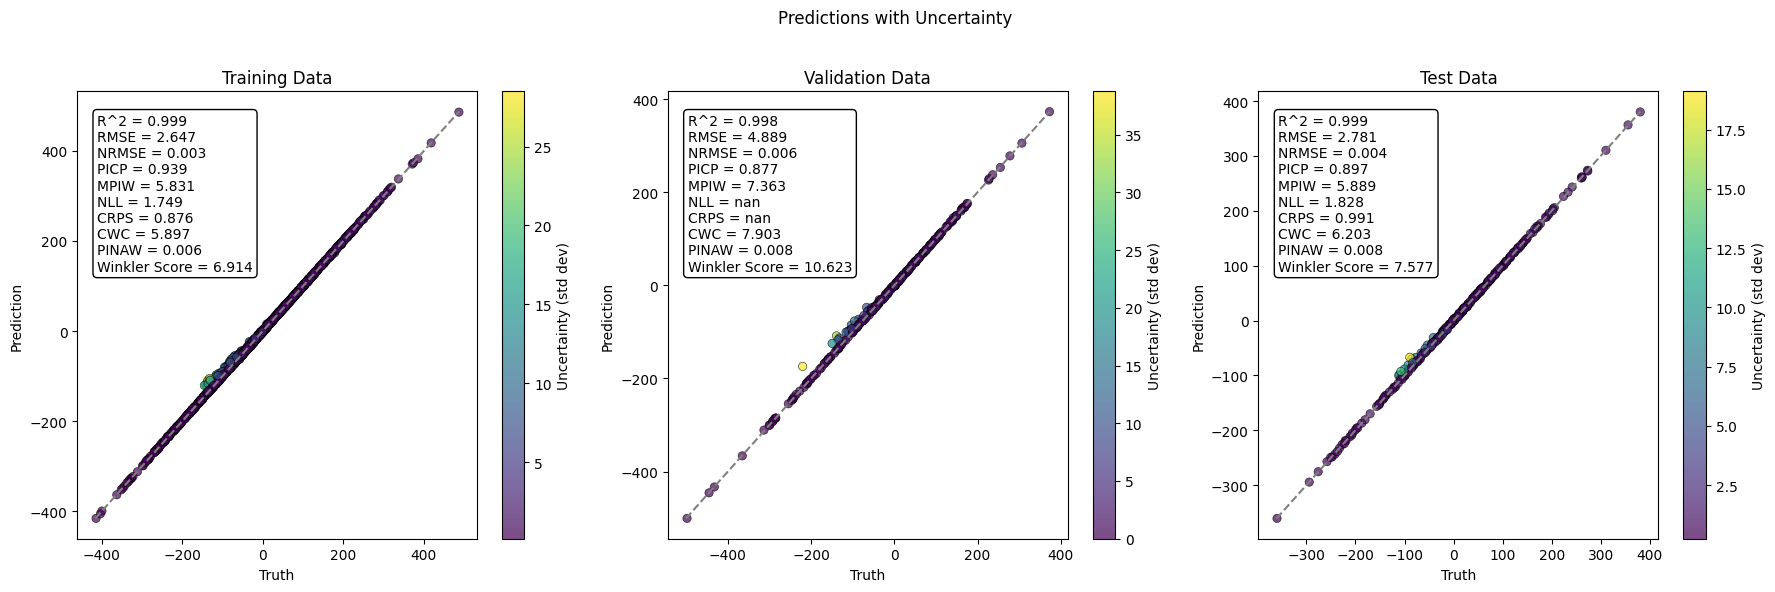

In [26]:
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Plot the predictions
plot_predictions_with_uncertainty(
    pred_train,
    pred_train_std,
    y_train_real,
    pred_val,
    pred_val_std,
    y_val_real,
    pred_test,
    pred_test_std,
    y_test_real,
    metrics_to_display=None,  # Display all metrics
)

# Bayesian Neural Network (BNN)


## Epistemic Uncertainty Predictions
We will turn off the aleatoric output layer and instead train an epistemic BNN model (of varying number of layers). Predictions will be made using Monte Carlo methods.

In [27]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Create the data holder for training/validation (the test set should be held separate from any model training)
dataset = TensorDataset(
    torch.from_numpy(x_train).float(), torch.from_numpy(y_train).float()
)
dataset_val = TensorDataset(
    torch.from_numpy(x_val).float(), torch.from_numpy(y_val).float()
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=True)

In [28]:
from ptmelt.models import BayesianNeuralNetwork
from torchinfo import summary
from torch import nn, optim

# Create the model
bnn_model = BayesianNeuralNetwork(
    num_features=n_features,
    num_outputs=n_targets,
    width=width,
    depth=depth,
    act_fun=act_fun,
    l1_reg=l1_reg,
    l2_reg=l2_reg,
    input_dropout=0.0,  # Remove input dropout
    dropout=0.0,  # Remove dropout
    batch_norm=batch_norm,
    batch_norm_type=batch_norm_type,
    output_activation=output_activation,
    # num_mixtures=0,
)

# Build the model and print the summary
bnn_model.build()
print(summary(bnn_model, input_size=(1, n_features)))

# Define the loss function and optimizer for training
criterion = bnn_model.get_loss_fn(mse_weight=1.0)
optimizer = bnn_model.get_optimizer("Adam", lr=learn_rate)
scheduler = bnn_model.get_scheduler(
    "ReduceLROnPlateau",
    optimizer,
    factor=0.5,
    patience=50,
    min_lr=1e-6,
    mode="min",
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=10,
)

print(f"Optimizer: {optimizer}")
print(f"Scheduler: {scheduler}")

Layer (type:depth-idx)                        Output Shape              Param #
BayesianNeuralNetwork                         [1, 3]                    --
├─BayesianBlock: 1-1                          [1, 8]                    --
│    └─ModuleDict: 2-1                        --                        --
│    │    └─MELTBayesianDenseFlipOut: 3-1     [1, 8]                    176
│    │    └─ReLU: 3-2                         [1, 8]                    --
│    │    └─MELTBayesianDenseFlipOut: 3-3     [1, 8]                    144
│    │    └─ReLU: 3-4                         [1, 8]                    --
├─ModuleDict: 1-2                             --                        320
│    └─DefaultOutput: 2-2                     [1, 3]                    --
│    │    └─MELTBayesianDenseFlipOut: 3-5     [1, 3]                    54
│    │    └─Identity: 3-6                     [1, 3]                    --
Total params: 694
Trainable params: 694
Non-trainable params: 0
Total mult-adds (Units.MEGAB

In [29]:
# Fit the model using the built-in training loop
n_epochs = 5000
bnn_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    stopping=True,
    num_epochs=n_epochs,
    verbose=True,
)

history = bnn_model.history

  0%|          | 14/5000 [00:00<02:03, 40.43it/s]

Epoch 10, Loss: 1.1652, Val Loss: 7.7151


  0%|          | 24/5000 [00:00<02:01, 40.95it/s]

Epoch 20, Loss: 0.9916, Val Loss: 7.2021


  1%|          | 34/5000 [00:00<02:00, 41.19it/s]

...

Epoch 2350, Loss: 0.1483, Val Loss: 1.0146


 47%|████▋     | 2366/5000 [00:56<01:03, 41.50it/s]

Epoch 2360, Loss: 0.1519, Val Loss: 1.0145


 48%|████▊     | 2375/5000 [00:57<01:03, 41.50it/s]

Epoch 2370, Loss: 0.1493, Val Loss: 1.0146
Stopping training at epoch 2376 due to learning rate reaching minimum 1e-06.


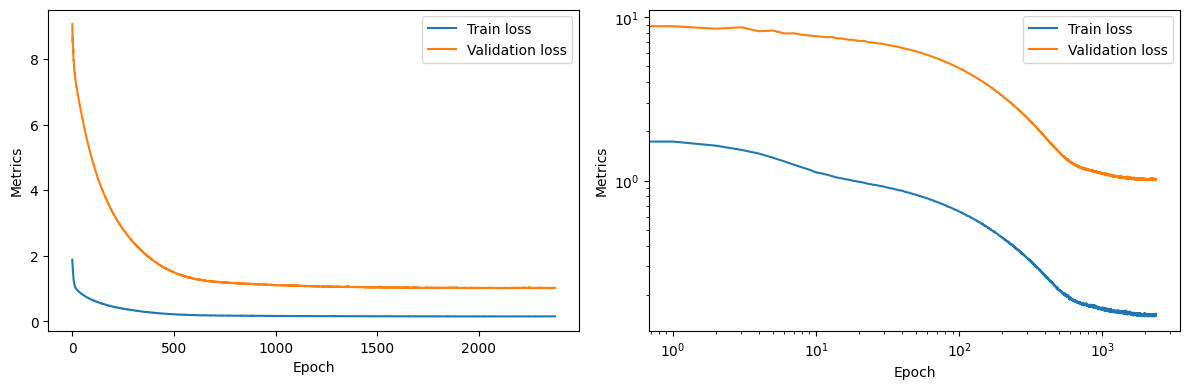

In [30]:
from ptmelt.utils.visualization import plot_history

# Plot the training history
plot_history(history, metrics=["loss"], plot_log=True)

In [31]:
from ptmelt.utils.evaluation import ensemble_predictions

# Make ensemble predictions using MC Dropout
n_iter = 100
pred_train_mean, pred_train_std = ensemble_predictions(
    bnn_model,
    x_train,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_val_mean, pred_val_std = ensemble_predictions(
    bnn_model,
    x_val,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_test_mean, pred_test_std = ensemble_predictions(
    bnn_model,
    x_test,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)

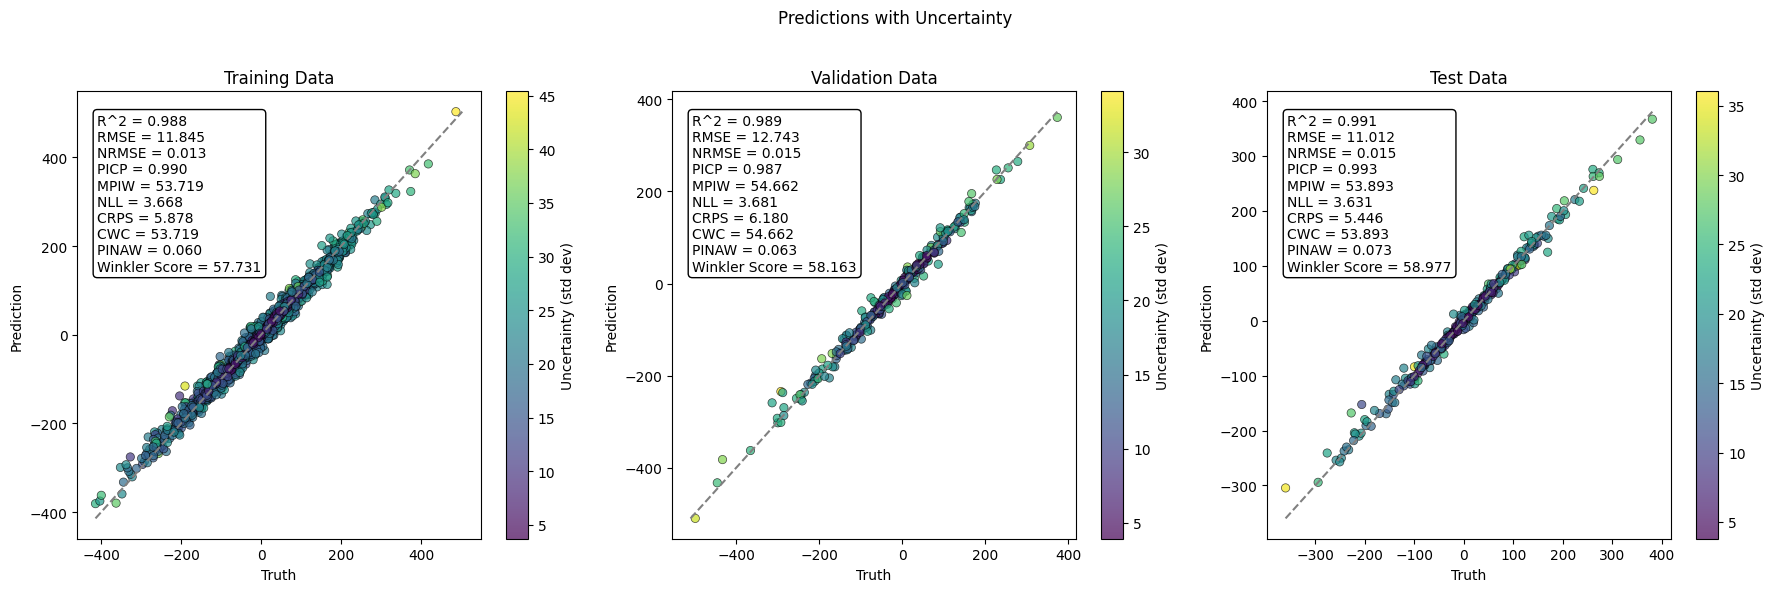

In [32]:
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Plot MC Dropout predictions
plot_predictions_with_uncertainty(
    pred_train_mean,
    pred_train_std,
    y_train_real,
    pred_val_mean,
    pred_val_std,
    y_val_real,
    pred_test_mean,
    pred_test_std,
    y_test_real,
    metrics_to_display=None,  # Display all metrics
)

The BNN can also use mixtures for the output layers which (in this case) will provide a better estimate for the uncertainty since all uncertainty is aleatoric in nature (data-based).